# Load libraries

In [11]:
from pathlib import Path

import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from cellpose import models
# Import time so we can measure how long Cellpose takes to run.
import time
# Import torch so we can synchronize the GPU before and after timing.
# GPU operations can be asynchronous, so synchronization makes timing more accurate.
import torch
import torch
import warnings

warnings.filterwarnings(
    "ignore",
    message="Sparse invariant checks are implicitly disabled.*"
)
# make sure you matplotlib can generate plots inline inside notebook
%matplotlib inline 


# Load images to test

In [12]:
# ============================================================
# Import a matched DAPI image and one non-DAPI marker image
# ============================================================

# We are using pathlib because it makes file paths easier to read and combine.
# This is especially useful here because the MACSima filenames are long.
from pathlib import Path

# tifffile is used to read microscopy TIFF files.
import tifffile as tiff

# NumPy is used for numerical operations on image arrays.
import numpy as np

# matplotlib is used to display the images inside the Jupyter notebook.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Define the folder containing the MACSima TIFF files
# ------------------------------------------------------------

# In this export, the MACSima data is not stored as one single multi-channel TIFF.
# Instead, each channel/marker appears to be stored as a separate TIFF file.
#
# The folder contains many files with names such as:
#   C-026_S-000_S_DAPI_..._A-DAPI.tif
#   C-026_S-000_S_FITC_..._A-CD326_C-REA977.tif
#
# These separate files correspond to different channels/markers from the same ROI.
folder = Path(
    "/workspace/Data/2026_03_05 JE E27_004 Slide 1 (Rack 01 Well A01 ROI 1)"
)


# ------------------------------------------------------------
# 2. Define the two files we want to load
# ------------------------------------------------------------

# For this first two-channel Cellpose-SAM test, we choose files that match on:
#
#   C-026
#   S-000
#   S
#   R-01
#   W-A01
#   ROI-01
#
# This is important because it means the two images are likely from the same
# acquisition group and same spatial region.
#
# The DAPI image will be used as the nuclear channel.
# DAPI stains DNA, so it highlights nuclei.
dapi_filename = "C-026_S-000_S_DAPI_R-01_W-A01_ROI-01_A-DAPI.tif"

# The CD326 image will be used as a possible cell-body / membrane helper channel.
# CD326 is also known as EpCAM and is often associated with epithelial cells.
# This does not mean it labels every cell, but it is a reasonable first marker
# to test as the second Cellpose input channel.
marker_filename = "C-026_S-000_S_FITC_R-01_W-A01_ROI-01_A-CD326_C-REA977.tif"


# ------------------------------------------------------------
# 3. Build the full file paths
# ------------------------------------------------------------

# In pathlib, the / operator joins a folder path with a filename.
# It does not mean mathematical division here.
dapi_path = folder / dapi_filename
marker_path = folder / marker_filename


# ------------------------------------------------------------
# 4. Check that the files exist
# ------------------------------------------------------------

# This is a useful sanity check before trying to read the images.
# If either prints False, then the filename or folder path is wrong.
print("DAPI file exists:", dapi_path.exists())
print("DAPI path:", dapi_path)

print("\nMarker file exists:", marker_path.exists())
print("Marker path:", marker_path)


# ------------------------------------------------------------
# 5. Read the TIFF images
# ------------------------------------------------------------

# Each TIFF is expected to be a single 2D image with shape:
#   height x width
#
# Earlier, when we loaded one file, we saw:
#   Shape: (869, 1160)
#
# That means one 2D image, not a multi-channel stack.
dapi_img = tiff.imread(dapi_path)
marker_img = tiff.imread(marker_path)


# ------------------------------------------------------------
# 6. Inspect the loaded images
# ------------------------------------------------------------

# Shape tells us the dimensions of the image.
# For a 2D image, it should be:
#   (height, width)
#
# Dtype tells us the pixel data type.
# Microscopy images are often uint16.
#
# Min and max tell us the darkest and brightest pixel values.
print("\nDAPI image information")
print("Shape:", dapi_img.shape)
print("Dtype:", dapi_img.dtype)
print("Min:", dapi_img.min())
print("Max:", dapi_img.max())

print("\nMarker image information")
print("Shape:", marker_img.shape)
print("Dtype:", marker_img.dtype)
print("Min:", marker_img.min())
print("Max:", marker_img.max())


# ------------------------------------------------------------
# 7. Check that the two images have the same shape
# ------------------------------------------------------------

# Cellpose expects the two channels to be spatially aligned and the same size.
# If the shapes differ, we should not combine them directly.
if dapi_img.shape != marker_img.shape:
    raise ValueError(
        f"The DAPI and marker images have different shapes: "
        f"DAPI={dapi_img.shape}, marker={marker_img.shape}"
    )

print("\nShape check passed: DAPI and marker image have the same dimensions.")


DAPI file exists: True
DAPI path: /workspace/Data/2026_03_05 JE E27_004 Slide 1 (Rack 01 Well A01 ROI 1)/C-026_S-000_S_DAPI_R-01_W-A01_ROI-01_A-DAPI.tif

Marker file exists: True
Marker path: /workspace/Data/2026_03_05 JE E27_004 Slide 1 (Rack 01 Well A01 ROI 1)/C-026_S-000_S_FITC_R-01_W-A01_ROI-01_A-CD326_C-REA977.tif

DAPI image information
Shape: (869, 1160)
Dtype: uint16
Min: 0
Max: 52360

Marker image information
Shape: (869, 1160)
Dtype: uint16
Min: 0
Max: 7230

Shape check passed: DAPI and marker image have the same dimensions.


# Visualize images side by side

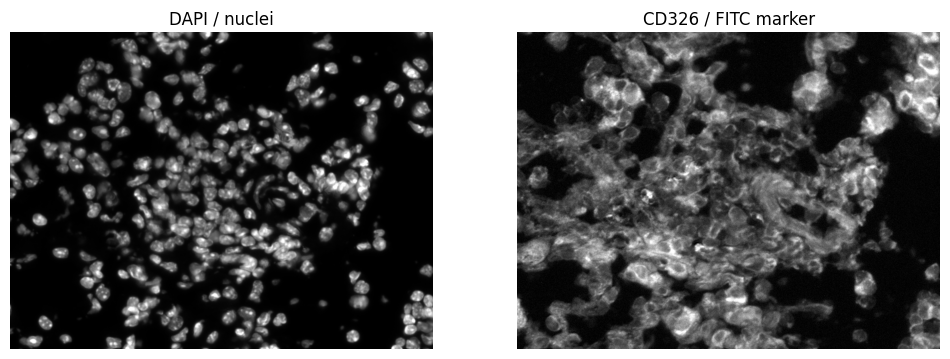

In [13]:
# ------------------------------------------------------------
# 8. Display the two images side by side
# ------------------------------------------------------------

# We use percentile-based display contrast.
#
# np.percentile(image, 1) gives a low intensity value.
# np.percentile(image, 99.8) gives a high intensity value.
#
# Passing these values to vmin and vmax tells matplotlib:
#   values <= vmin are displayed as black
#   values >= vmax are displayed as white
#
# This improves visual contrast but does not modify the original image data.
plt.close("all")

plt.figure(figsize=(12, 6))

# Display DAPI.
plt.subplot(1, 2, 1)
plt.imshow(
    dapi_img,
    cmap="gray",
    vmin=np.percentile(dapi_img, 1),
    vmax=np.percentile(dapi_img, 99.8)
)
plt.title("DAPI / nuclei")
plt.axis("off")

# Display CD326 marker.
plt.subplot(1, 2, 2)
plt.imshow(
    marker_img,
    cmap="gray",
    vmin=np.percentile(marker_img, 1),
    vmax=np.percentile(marker_img, 99.8)
)
plt.title("CD326 / FITC marker")
plt.axis("off")

plt.show()

# Preprocess: combines images for Cellpose

In [14]:
# For Cellpose-style testing, we want to combine the two separate TIFF files
# into one array.
#
# Here we create an array with shape:
#   height x width x channels
#
# The last dimension contains the two channels:
#   channel 0 = DAPI
#   channel 1 = CD326 marker
#
# This is useful because many Python image tools expect multi-channel images
# in this format:
#   Y, X, C
#
# Important:
# This does not create a new biological image. It just combines two aligned
# grayscale images into one Python array for analysis.
two_channel_img = np.stack(
    [dapi_img, marker_img],
    axis=-1
)

print("\nTwo-channel image information")
print("Shape:", two_channel_img.shape)
print("Dtype:", two_channel_img.dtype)

print("\nChannel meaning:")
print("two_channel_img[:, :, 0] = DAPI / nuclei")
print("two_channel_img[:, :, 1] = CD326 / FITC marker")


Two-channel image information
Shape: (869, 1160, 2)
Dtype: uint16

Channel meaning:
two_channel_img[:, :, 0] = DAPI / nuclei
two_channel_img[:, :, 1] = CD326 / FITC marker


# Run Cellpose-SAM on the test image

In [15]:
# Define where to save the Cellpose mask.
# This is the output TIFF file that will contain the segmentation labels.
output_path = "/workspace/Results/test_cellpose_mask.tif"


# Load the Cellpose-SAM model.
#
# gpu=True:
#   tells Cellpose to use the NVIDIA GPU.
#
# model_type="cpsam":
#   selects the Cellpose-SAM model.
#
# Important:
#   This creates/loads the model, but it does not yet run segmentation.
#   Segmentation happens later when we call model.eval(...).
model = models.CellposeModel(
    gpu=True,
    model_type="cpsam"
)


# Run Cellpose-SAM segmentation.
#
# two_channel_img has shape:
#   height x width x channels
#
# In our case:
#   two_channel_img[:, :, 0] = DAPI
#   two_channel_img[:, :, 1] = CD326 / FITC
#
# Important Cellpose-SAM detail:
#   For Cellpose-SAM, the old Cellpose channel argument is no longer used
#   to specify "cytoplasm channel" and "nuclear channel".
#
#   In older Cellpose models, we might use something like:
#       channels=[2, 1]
#   to say:
#       segment channel 2 and use channel 1 as the nuclear channel.
#
#   However, Cellpose-SAM documentation states that channels are no longer
#   an input in that way. Cellpose-SAM uses the first 3 channels of the image
#   and is trained to be invariant to the order of those channels.
#
# Our practical test confirmed this:
#   model.eval(two_channel_img, channels=[0, 0])
#   and
#   model.eval(two_channel_img, channels=[2, 1])
#   produced exactly the same mask.
#
# Therefore, for Cellpose-SAM, the important thing is to construct the input
# image correctly before calling model.eval().
#
# Here, we pass the two-channel image directly:
#   channel 0 = DAPI
#   channel 1 = CD326
#
# Cellpose-SAM will use the available channels from the input image.
# If more than 3 channels are provided, Cellpose-SAM will only use the first 3.

# Before starting the timer, synchronize the GPU.
# This ensures any previous GPU work has finished before timing begins.
if torch.cuda.is_available():
    torch.cuda.synchronize()

# Start the timer immediately before Cellpose segmentation.
start_time = time.perf_counter()

# Run Cellpose-SAM segmentation.
result = model.eval(
    two_channel_img,
    diameter=None
)

# After segmentation, synchronize the GPU again.
# This ensures the GPU has fully finished the Cellpose operation before timing stops.
if torch.cuda.is_available():
    torch.cuda.synchronize()

# Stop the timer immediately after Cellpose segmentation is complete.
end_time = time.perf_counter()

# Calculate elapsed time.
elapsed_seconds = end_time - start_time
elapsed_minutes = elapsed_seconds / 60


# Cellpose returns several outputs inside result.
#
# result[0] is the labelled segmentation mask.
#
# In the mask:
#   0 = background
#   1 = object 1
#   2 = object 2
#   3 = object 3
#   etc.
masks = result[0]


# result[1] contains Cellpose flow information.
#
# This is useful for advanced diagnostics and visualising how Cellpose
# internally assigns pixels to objects, but we do not need it for this
# first segmentation test.
flows = result[1]


# result[2] contains style/features information.
#
# This is internal model information. We keep it for completeness,
# but we do not need to interpret it at this stage.
styles = result[2]


# Print basic information about the segmentation output.
#
# masks.shape should match the height and width of the input image.
#
# masks.max() gives the number of segmented objects because each object
# receives a unique integer label.
print("Mask shape:", masks.shape)
print("Number of segmented objects:", masks.max())

# Print how long Cellpose-SAM took to run.
# We show both minutes and seconds:
#   minutes = useful for longer benchmark runs
#   seconds = useful for short tests
print(f"Cellpose-SAM execution time: {elapsed_minutes:.2f} minutes ({elapsed_seconds:.1f} seconds)")


Mask shape: (869, 1160)
Number of segmented objects: 291
Cellpose-SAM execution time: 0.02 minutes (1.1 seconds)


In [16]:
# Save the mask as a TIFF file.
# Each segmented object has a different integer label:
#   0 = background
#   1 = object 1

#   2 = object 2
#   etc.
tiff.imwrite(output_path, masks.astype(np.uint16))

print("Saved mask to:", output_path)

Saved mask to: /workspace/Results/test_cellpose_mask.tif


# Visualize Cellpose result

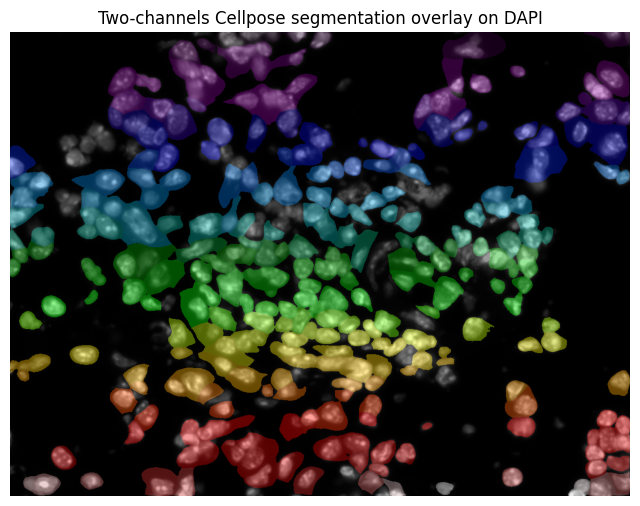

In [17]:
# Close any matplotlib figures that are still open in memory.
plt.close("all")

# Select the DAPI channel from the two-channel image.
# two_channel_img[:, :, 0] = DAPI / nuclei
background_img = two_channel_img[:, :, 0]

# Create a new figure.
plt.figure(figsize=(8, 8))

# Show DAPI as the grayscale background.
plt.imshow(
    background_img,
    cmap="gray",
    vmin=np.percentile(background_img, 1),
    vmax=np.percentile(background_img, 99.8)
)

# Overlay the Cellpose segmentation mask.
plt.imshow(
    masks,
    cmap="nipy_spectral",
    alpha=0.4,
    vmin=0,
    vmax=masks.max()
)

# Add title and hide axes.
plt.title("Two-channels Cellpose segmentation overlay on DAPI")
plt.axis("off")

# Display the plot.
plt.show()

# Compare segmentation: only Dapi image, only non-DAPI image and both images

In [18]:
# DAPI only: single 2D image
result_dapi_only = model.eval(
    dapi_img,
    diameter=None
)
masks_dapi_only = result_dapi_only[0]

print("DAPI only objects:", masks_dapi_only.max())


# CD326 only: single 2D image
result_cd326_only = model.eval(
    marker_img,
    diameter=None
)
masks_cd326_only = result_cd326_only[0]

print("CD326 only objects:", masks_cd326_only.max())


# DAPI + CD326: two-channel image
result_two_channel = model.eval(
    two_channel_img,
    diameter=None
)
masks_two_channel = result_two_channel[0]

print("DAPI + CD326 objects:", masks_two_channel.max())

DAPI only objects: 396
CD326 only objects: 164
DAPI + CD326 objects: 291


Output says the number of objects identified changed between the tests, so the combined stack of images (DAPI + CD326) had an impact on cell segmentation. 
It seems DAPI-only segmentation identified more objects.

# Visualize segmentation using only Dapi channel

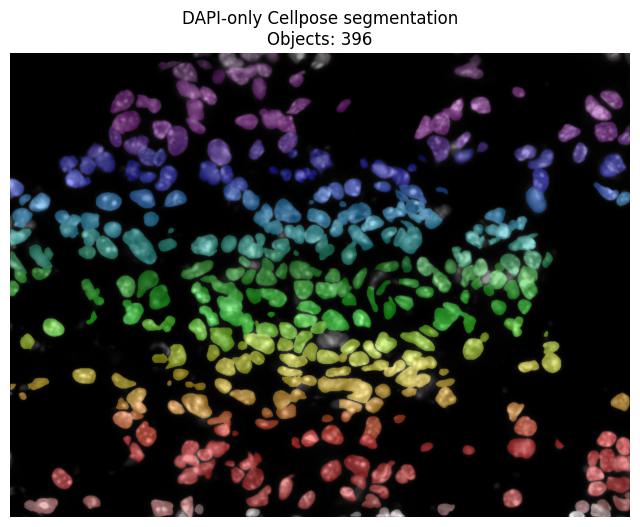

In [19]:
# Plot the Cellpose-SAM segmentation result from the DAPI-only input.
#
# Here we use:
#   background image = dapi_img
#   segmentation mask = masks_dapi_only
#
# This lets us evaluate how well Cellpose-SAM segments nuclei/cell-like objects
# when only the DAPI channel is provided.

# Close any previous matplotlib figures still open in memory.
plt.close("all")

# Create a new figure.
plt.figure(figsize=(8, 8))

# Display the original DAPI image in grayscale.
# DAPI highlights nuclei, so this is the correct background
# for evaluating the DAPI-only segmentation.
plt.imshow(
    dapi_img,
    cmap="gray",
    vmin=np.percentile(dapi_img, 1),
    vmax=np.percentile(dapi_img, 99.8)
)

# Overlay the DAPI-only Cellpose segmentation mask.
#
# Each segmented object has a unique integer label:
#   0 = background
#   1 = object 1
#   2 = object 2
#   etc.
#
# cmap="nipy_spectral" gives different labels different colours.
# alpha=0.4 makes the mask semi-transparent so the DAPI signal remains visible.
plt.imshow(
    masks_dapi_only,
    cmap="nipy_spectral",
    alpha=0.4,
    vmin=0,
    vmax=masks_dapi_only.max()
)

# Add a title showing the number of segmented objects.
plt.title(f"DAPI-only Cellpose segmentation\nObjects: {masks_dapi_only.max()}")

# Hide axes for cleaner microscopy visualisation.
plt.axis("off")

# Show the plot in the notebook.
plt.show()

DAPI-only input produced 396 segmented objects and visually gave a better nuclear segmentation than the DAPI + CD326 input, which produced 291 objects. Since DAPI directly labels nuclei, this supports using DAPI-only Cellpose-SAM as the nuclear segmentation baseline. The CD326 channel should instead be evaluated as a helper channel for whole-cell or cytoplasmic segmentation, not necessarily for nuclei-only segmentation.